# 2.4 Hybrid physics–ML modeling

The diffusion term in Budyko–Sellers is a **closure**: it stands in for the poleward
energy transport of weather systems the model does not resolve, compressing all of
storm-track dynamics into one coefficient. Replacing closures with ones learned from data is
the central promise of machine learning for climate modeling.

This chapter builds a true model whose transport the coarse model misrepresents,
inserts a small neural network as a transport correction, and trains it two ways:

- **Offline** (*a priori*): fit the network to diagnosed transport values, by ordinary
  supervised regression. Requires knowing the true fluxes — data that in reality only
  a field campaign or a high-resolution simulation can provide.
- **Online** (*a posteriori*): run the hybrid model, compare its **climate** to
  observations, and differentiate the misfit through the entire simulation back to the
  network weights {cite}`frezat2022posteriori,kochkov2021machine`. Requires only
  observable outputs — but requires the model to be differentiable.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [3]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

## A "true" model with structure the coarse model lacks

In the "true" model, diffusivity peaks in the mid-latitude storm tracks at nearly twice
the background value. The coarse model keeps diffusivity constant, this is a *structural*
error no constant-$D$ calibration can remove. The generalized integrator below accepts
a per-edge diffusivity and an optional extra flux (the future neural network's slot):

coarse-model climate error: 4.49 K RMSE


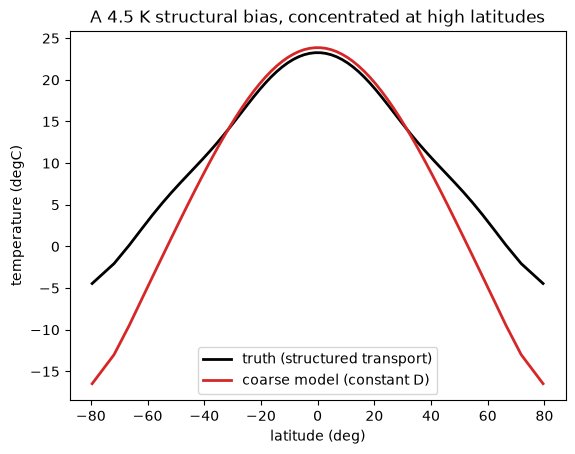

In [4]:
lat_edge = jnp.rad2deg(jnp.arcsin(x_edge[1:-1]))
D_truth = 0.48 * (1.0 + 0.9 * jnp.exp(-(((jnp.abs(lat_edge) - 45.0) / 15.0) ** 2)))

def integrate2(T0, D_edge, extra_flux=None, n_years=30):
    """Budyko-Sellers with per-edge diffusivity and an optional learned flux."""
    def tendency(T):
        absorbed = Q * s_x * (1.0 - albedo(T, default_params))
        emitted = A_olr + B_olr * T
        flux = D_edge * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx
        if extra_flux is not None:
            flux = flux + extra_flux(T)
        flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])
        return absorbed - emitted + jnp.diff(flux) / dx
    def step(T, _):
        return T + dt / heat_capacity * tendency(T), T
    T_final, traj = jax.lax.scan(step, T0, None, length=int(n_years * 365.25 * 86400 / dt))
    return T_final, traj

T_truth, truth_traj = integrate2(T_start, D_truth)
T_coarse, _ = integrate2(T_start, 0.48)
rmse = lambda a, b: float(jnp.sqrt(jnp.mean((a - b) ** 2)))
print(f"coarse-model climate error: {rmse(T_coarse, T_truth):.2f} K RMSE")

plt.plot(lat, T_truth, "k", lw=2, label="truth (structured transport)")
plt.plot(lat, T_coarse, "C3", lw=2, label="coarse model (constant D)")
plt.xlabel("latitude (deg)"); plt.ylabel("temperature (degC)"); plt.legend()
plt.title("A 4.5 K structural bias, concentrated at high latitudes")
plt.show()

The extra mid-latitude transport in the "true model" carries enough heat poleward to melt
the ice caps; the coarse model, missing it, keeps them, a nearly 20 K polar error and
a qualitatively different climate. This is the kind of bias a learned closure should
fix.

## The closure

A three-layer perceptron maps *local* conditions at each cell edge — temperature,
temperature gradient, and position — to a flux correction. Locality is a physical
choice (transport closures should not act at a distance), and the $(1-x^2)$ factor
guarantees no flux through the poles. Note what the network is *not* told: the shape
of $D_\mathrm{truth}$.

In [5]:
import equinox as eqx
import optax

def edge_features(T):
    T_edge = 0.5 * (T[:-1] + T[1:])
    grad_T = jnp.diff(T) / dx
    return jnp.stack([T_edge / 30.0, grad_T / 100.0, x_edge[1:-1]], axis=-1)

class TransportClosure(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, key):
        self.mlp = eqx.nn.MLP(in_size=3, out_size=1, width_size=32, depth=2, key=key)
    def __call__(self, T):
        raw = jax.vmap(self.mlp)(edge_features(T))[:, 0]
        return 50.0 * (1.0 - x_edge[1:-1] ** 2) * raw     # W m^-2 scale

closure0 = TransportClosure(jax.random.key(2))
n_weights = sum(a.size for a in jax.tree.leaves(eqx.filter(closure0, eqx.is_array)))
print(f"closure parameters: {n_weights}")

closure parameters: 1217


## Offline training: regression on diagnosed fluxes

Pretend a high-resolution campaign has measured the transport the coarse model misses,
at snapshots along the truth's evolution. Supervised learning on those diagnosed
fluxes is standard regression — no differentiable model required:

In [6]:
snapshots = truth_traj[jnp.arange(200, 40000, 200)]        # 199 states along the spin-up

def missing_flux(T):
    return (D_truth - 0.48) * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx

flux_targets = jax.vmap(missing_flux)(snapshots)

def train(model, loss_fn, learning_rate, n_iters):
    opt = optax.adam(learning_rate)
    opt_state = opt.init(eqx.filter(model, eqx.is_array))
    @eqx.filter_jit
    def one(model, opt_state):
        L, g = eqx.filter_value_and_grad(loss_fn)(model)
        updates, opt_state = opt.update(g, opt_state)
        return eqx.apply_updates(model, updates), opt_state, L
    for i in range(n_iters):
        model, opt_state, L = one(model, opt_state)
    return model, float(L)

def offline_loss(model):
    return jnp.mean((jax.vmap(model)(snapshots) - flux_targets) ** 2)

closure_offline, L = train(closure0, offline_loss, 3e-3, 1500)
print(f"offline: final flux-fitting loss {L:.4f} (W m^-2)^2")

offline: final flux-fitting loss 0.0065 (W m^-2)^2


## Online training: through the solver

Now suppose no flux measurements exist, only the observable climate (the equilibrium
temperature profile). The online loss runs the *hybrid* model for twelve years and
compares its output to the truth's climate; `grad` carries the misfit backward through
every time step to the network weights. Two variants: one trained on the full profile,
one on only the five observed latitudes of Chapter 2.3.

In [7]:
T_coarse_eq, _ = integrate2(T_start, 0.48)      # warm start for training rollouts

def online_loss(model):
    T_final, _ = integrate2(T_coarse_eq, 0.48, extra_flux=model, n_years=12)
    return jnp.mean((T_final - T_truth) ** 2)

obs_idx = jnp.array([jnp.argmin(jnp.abs(lat - l)) for l in [-60.0, -30.0, 0.0, 30.0, 60.0]])
def online_sparse_loss(model):
    T_final, _ = integrate2(T_coarse_eq, 0.48, extra_flux=model, n_years=12)
    return jnp.mean((T_final[obs_idx] - T_truth[obs_idx]) ** 2)

schedule = optax.exponential_decay(3e-3, transition_steps=150, decay_rate=0.5)
closure_online, L1 = train(closure0, online_loss, schedule, 500)
closure_sparse, L2 = train(closure0, online_sparse_loss, schedule, 500)
print(f"online (full profile): final loss {L1:.4f} K^2")
print(f"online (5 latitudes):  final loss {L2:.4f} K^2")

online (full profile): final loss 0.1171 K^2
online (5 latitudes):  final loss 0.0067 K^2


## The comparison

Each closure now runs inside the coarse model from the original cold start, for 40
years, longer than any training rollout, from a state none of them saw:

offline (flux data)      climate RMSE vs truth:  0.016 K
online (full profile)    climate RMSE vs truth:  0.342 K
online (5 latitudes)     climate RMSE vs truth:  0.643 K
no closure               climate RMSE vs truth:  4.494 K


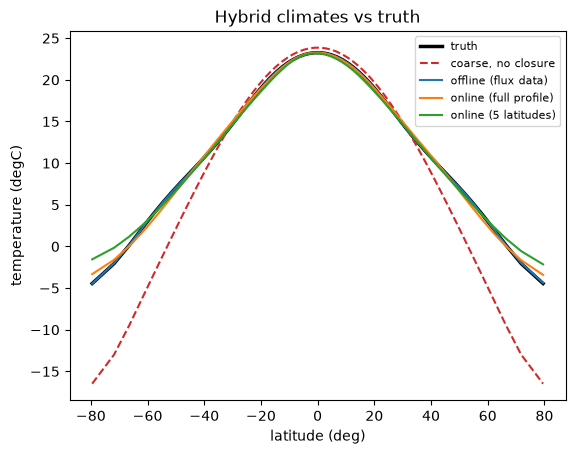

In [8]:
results = {}
for name, m in [("offline (flux data)", closure_offline),
                ("online (full profile)", closure_online),
                ("online (5 latitudes)", closure_sparse)]:
    T_final, _ = integrate2(T_start, 0.48, extra_flux=m, n_years=40)
    results[name] = T_final
    print(f"{name:24s} climate RMSE vs truth: {rmse(T_final, T_truth):6.3f} K")
print(f"{'no closure':24s} climate RMSE vs truth: {rmse(T_coarse, T_truth):6.3f} K")

plt.plot(lat, T_truth, "k", lw=2.5, label="truth")
plt.plot(lat, T_coarse, "C3", ls="--", label="coarse, no closure")
for (name, T_f), c in zip(results.items(), ["C0", "C1", "C2"]):
    plt.plot(lat, T_f, c, lw=1.5, label=name)
plt.xlabel("latitude (deg)"); plt.ylabel("temperature (degC)")
plt.legend(fontsize=8); plt.title("Hybrid climates vs truth")
plt.show()

All three hybrids remove nearly all of the 4.5 K structural bias. Reading the table
with the data requirements in mind:

- **Offline is excellent here, when its data exist.** The diagnosed-flux dataset
  determines the closure almost completely, and the model's strong damping keeps small
  flux errors from compounding. The result would look very different in a model where
  errors grow: in turbulence, offline-trained closures are notorious for drifting or
  destabilizing when coupled, precisely because a-priori skill does not measure the
  coupled feedback loop {cite}`frezat2022posteriori`. Part 3.1 introduces the
  error-growth regime where that distinction bites.
- **Online needs only what is observable.** Within half a kelvin of truth using
  nothing but the equilibrium temperature profile and within a kelvin using *five
  numbers per observation time*. No flux was ever measured. This is the regime real
  Earth-system closure learning lives in, and it is unavailable without a
  differentiable model: the gradient of the 12-year climate with respect to each of
  the 1,000+ network weights is what `grad` delivered through the solver.
- **The two can be combined**. offline pre-training followed by online fine-tuning
  may inherit the best of both.

**Exercises.**
1. Give the offline network a fraction of the snapshots (every 2,000th step). How does
   its coupled RMSE degrade compared to the online closures?
2. The online closures were never told to conserve energy. Check: integrate each
   learned flux's divergence over the globe. How large is the spurious source, and
   how would you constrain it to zero by construction?
3. Train the sparse-online closure with observations at 2 latitudes instead of 5.
   Where does the hybrid climate degrade first?